# Experimentation for Analyzing W^O Output Projection Matrices for Efficient KV Cache Optimization

In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('default')
from transformers import LlamaModel, AutoTokenizer
import seaborn as sns

def extract_wo_matrices(model):
    """
    Extract W^O matrices from all layers - works with both Llama and Mistral models
    Returns: List of W^O matrices, one per layer
    """
    wo_matrices = []
    
    # Auto-detect model structure
    if hasattr(model, 'layers'):
        # Llama base models
        layers = model.layers
        num_layers = model.config.num_hidden_layers
    elif hasattr(model, 'model') and hasattr(model.model, 'layers'):
        # Mistral and Llama CausalLM models
        layers = model.model.layers
        num_layers = model.config.num_hidden_layers
    else:
        raise ValueError(f"Cannot detect layer structure for {type(model)}")
    
    for layer_idx in range(num_layers):
        # Access the output projection weight from each transformer layer
        wo_weight = layers[layer_idx].self_attn.o_proj.weight
        wo_matrices.append(wo_weight.detach().cpu())
    
    return wo_matrices


def extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim):
    """
    Split W^O matrix into per-head blocks
    wo_matrix: [hidden_size, hidden_size] tensor
    Returns: List of per-head blocks [hidden_size, head_dim]
    """
    blocks = []
    for head_idx in range(num_heads):
        start_idx = head_idx * head_dim
        end_idx = (head_idx + 1) * head_dim
        head_block = wo_matrix[:, start_idx:end_idx]
        blocks.append(head_block)
    
    return blocks

def compute_head_importance_all_layers(model):
    """
    Compute W^O-based importance scores for all heads across all layers
    Works with both Llama and Mistral models
    """
    # Auto-detect model structure
    if hasattr(model, 'layers'):
        layers = model.layers
    elif hasattr(model, 'model') and hasattr(model.model, 'layers'):
        layers = model.model.layers
    else:
        raise ValueError(f"Cannot detect layer structure for {type(model)}")
    
    num_layers = model.config.num_hidden_layers
    num_heads = model.config.num_attention_heads
    head_dim = model.config.hidden_size // num_heads
    
    # Initialize importance matrix [layers, heads]
    importance_matrix = np.zeros((num_layers, num_heads))
    
    for layer_idx in range(num_layers):
        wo_weight = layers[layer_idx].self_attn.o_proj.weight.detach().cpu()
        
        # Extract per-head blocks
        head_blocks = extract_wo_blocks_per_head(wo_weight, num_heads, head_dim)
        
        # Compute Frobenius norm for each head block
        for head_idx, block in enumerate(head_blocks):
            importance_score = torch.norm(block, p='fro').item()
            importance_matrix[layer_idx, head_idx] = importance_score
    
    return importance_matrix


# def plot_head_importance_heatmap(importance_scores, model_name="Model", figsize=(12, 8)):
#     # Additional analysis: Layer-wise statistics
#     layer_avg = importance_scores.mean(axis=1)
#     layer_std = importance_scores.std(axis=1)

#     plt.figure(figsize=(12, 5))

#     plt.subplot(1, 2, 1)
#     plt.plot(range(len(layer_avg)), layer_avg, 'b-o')
#     plt.title('Average Head Importance per Layer')
#     plt.xlabel('Layer Index')
#     plt.ylabel('Average Importance')

#     plt.subplot(1, 2, 2)
#     plt.plot(range(len(layer_std)), layer_std, 'r-o')
#     plt.title('Head Importance Variance per Layer')
#     plt.xlabel('Layer Index')
#     plt.ylabel('Standard Deviation')

#     plt.tight_layout()
#     plt.show()

#     plt.figure(figsize=figsize)
#     sns.heatmap(importance_scores, 
#                 xticklabels=range(importance_scores.shape[1]), 
#                 yticklabels=range(importance_scores.shape[0]),
#                 cmap='viridis',
#                 cbar_kws={'label': 'Importance Score'})
#     plt.title(f'Head Importance Across All Layers ({model_name})')
#     plt.xlabel('Head Index')
#     plt.ylabel('Layer Index')
#     plt.tight_layout()
#     plt.show()
    
#     # Print basic stats
#     print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")
#     print(f"Importance ratio: {importance_scores.max() / importance_scores.min():.2f}x")
    
#     # Top 5 heads
#     print(f"\nTop 5 most important heads:")
#     flat_indices = np.argsort(importance_scores.flatten())[-5:]
#     for idx in reversed(flat_indices):
#         layer_idx, head_idx = np.unravel_index(idx, importance_scores.shape)
#         score = importance_scores[layer_idx, head_idx]
#         print(f"  Layer {layer_idx}, Head {head_idx}: {score:.3f}")

def plot_head_importance_heatmap(importance_scores, model_name="Model", figsize=(18, 12)):
    """
    Combined visualization of head importance heatmap and layer-wise statistics
    """
    layer_avg = importance_scores.mean(axis=1)
    layer_std = importance_scores.std(axis=1)

    # Create figure with custom layout
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 3, width_ratios=[3, 1, 1], height_ratios=[1, 1], hspace=0.3, wspace=0.3)

    # Large heatmap spanning both rows on the left
    ax_heatmap = fig.add_subplot(gs[:, 0])
    sns.heatmap(importance_scores, 
                xticklabels=range(importance_scores.shape[1]), 
                yticklabels=range(importance_scores.shape[0]),
                cmap='viridis',
                cbar_kws={'label': 'Importance Score'},
                ax=ax_heatmap)
    ax_heatmap.set_title(f'Head Importance Across All Layers\n({model_name})', fontsize=14, fontweight='bold')
    ax_heatmap.set_xlabel('Head Index', fontsize=12)
    ax_heatmap.set_ylabel('Layer Index', fontsize=12)

    # Average importance per layer (top right)
    ax_avg = fig.add_subplot(gs[0, 1:])
    ax_avg.plot(range(len(layer_avg)), layer_avg, 'b-o', linewidth=2, markersize=4)
    ax_avg.set_title('Average Head Importance per Layer', fontsize=12, fontweight='bold')
    ax_avg.set_xlabel('Layer Index', fontsize=10)
    ax_avg.set_ylabel('Average Importance', fontsize=10)
    ax_avg.grid(True, alpha=0.3)

    # Variance per layer (bottom right)
    ax_std = fig.add_subplot(gs[1, 1:])
    ax_std.plot(range(len(layer_std)), layer_std, 'r-o', linewidth=2, markersize=4)
    ax_std.set_title('Head Importance Variance per Layer', fontsize=12, fontweight='bold')
    ax_std.set_xlabel('Layer Index', fontsize=10)
    ax_std.set_ylabel('Standard Deviation', fontsize=10)
    ax_std.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Print basic stats
    print(f"\n{model_name} Analysis Summary:")
    print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")
    print(f"Importance ratio: {importance_scores.max() / importance_scores.min():.2f}x")
    print(f"Mean importance: {importance_scores.mean():.3f}")
    
    # Layer insights
    print(f"\nLayer-wise insights:")
    print(f"Highest avg layer: Layer {np.argmax(layer_avg)} (avg: {layer_avg.max():.3f})")
    print(f"Most variable layer: Layer {np.argmax(layer_std)} (std: {layer_std.max():.3f})")
    
    # Top 5 heads
    print(f"\nTop 5 most important heads:")
    flat_indices = np.argsort(importance_scores.flatten())[-5:]
    for idx in reversed(flat_indices):
        layer_idx, head_idx = np.unravel_index(idx, importance_scores.shape)
        score = importance_scores[layer_idx, head_idx]
        print(f"  Layer {layer_idx}, Head {head_idx}: {score:.3f}")

## Meta-Llama-3.1-8B-Instruct

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import LlamaModel, AutoTokenizer
import seaborn as sns

# Load the model (you'll need access to meta-llama models)
model_name = "meta-llama/Meta-Llama-3.1-8B-Instruct"
model = LlamaModel.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)


Loading checkpoint shards:  25%|██▌       | 1/4 [00:01<00:03,  1.18s/it]

Loading checkpoint shards: 100%|██████████| 4/4 [00:03<00:00,  1.28it/s]


In [7]:
# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")


Number of layers: 32
W^O matrix shape per layer: torch.Size([4096, 4096])
Model config - Hidden size: 4096
Model config - Number of heads: 32


In [8]:
# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")


Layer 0: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 1: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 2: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 3: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 4: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 5: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 6: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 7: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 8: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 9: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 10: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 11: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 12: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 13: Extracted 32 head blocks, each shape torch.Size([4096, 128])
Layer 14: Extrac

In [9]:
# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")


Importance matrix shape: (32, 32)
Score range: 3.516 to 12.812


/tmp/ipykernel_4070716/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


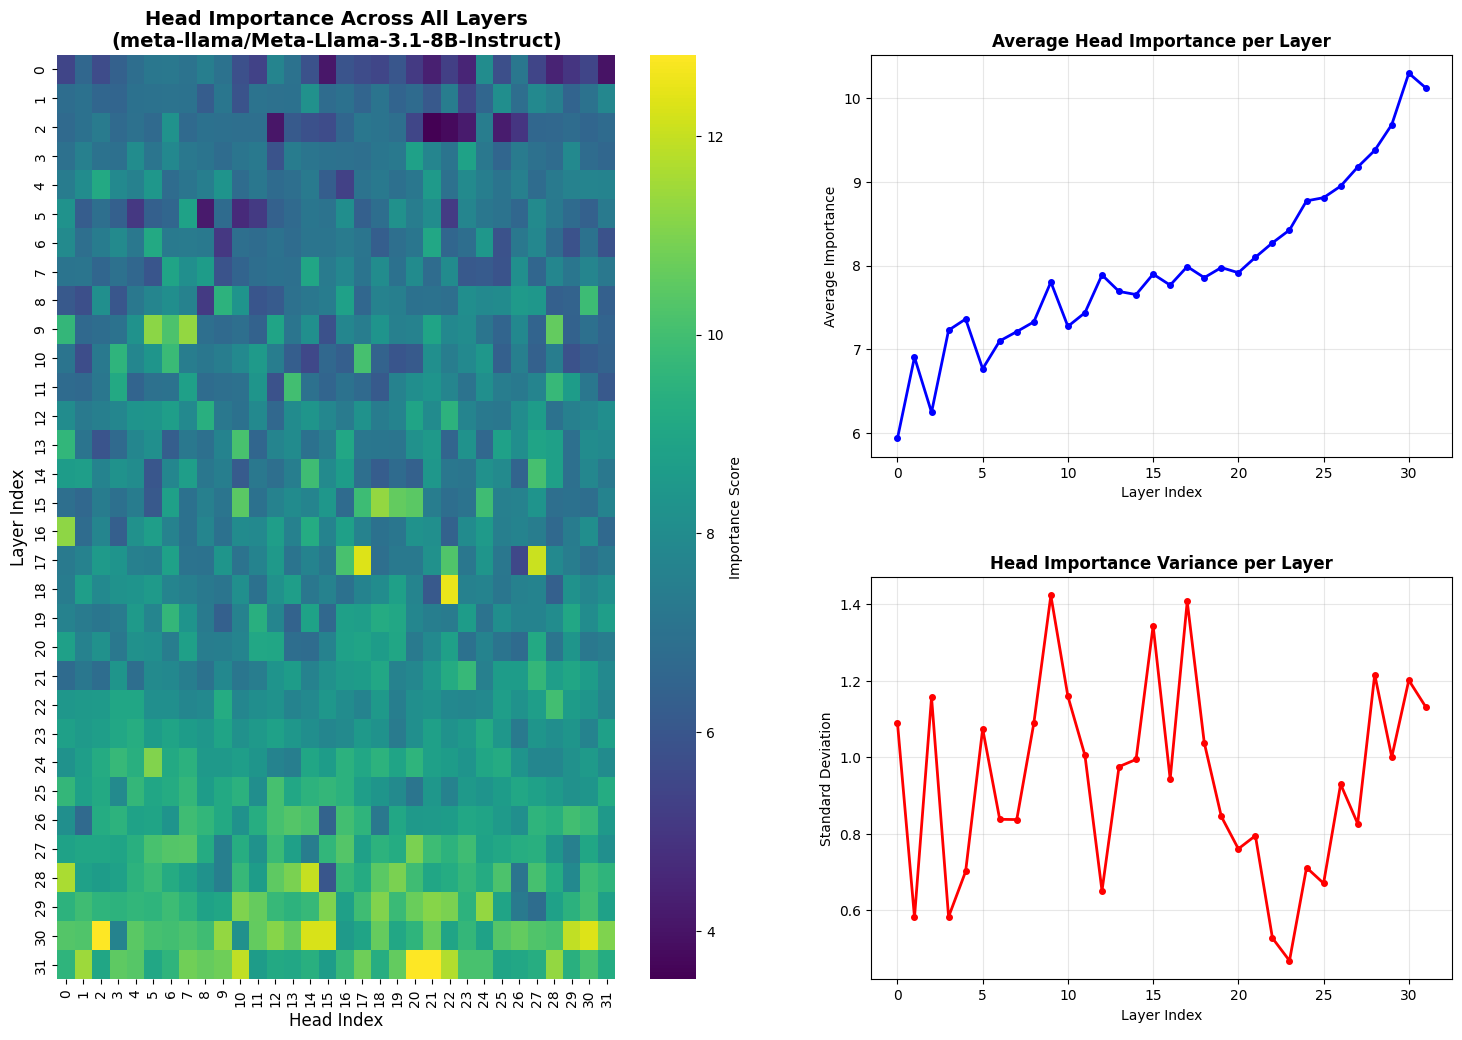


meta-llama/Meta-Llama-3.1-8B-Instruct Analysis Summary:
Score range: 3.516 to 12.812
Importance ratio: 3.64x
Mean importance: 7.975

Layer-wise insights:
Highest avg layer: Layer 30 (avg: 10.295)
Most variable layer: Layer 9 (std: 1.423)

Top 5 most important heads:
  Layer 31, Head 21: 12.812
  Layer 31, Head 20: 12.812
  Layer 30, Head 2: 12.812
  Layer 18, Head 22: 12.500
  Layer 17, Head 17: 12.312


In [7]:
plot_head_importance_heatmap(importance_scores, model_name)

In [16]:
def compute_cosine_similarity_matrix_fixed(wo_matrices, num_heads, head_dim):
    """
    Compute cosine similarity matrix between all W^O blocks across all layers
    Fixes BFloat16 type error by converting to float32
    """
    num_layers = len(wo_matrices)
    total_heads = num_layers * num_heads
    
    # Flatten all blocks into vectors
    blocks = []
    for layer_idx, wo_matrix in enumerate(wo_matrices):
        for head_idx in range(num_heads):
            start_idx = head_idx * head_dim
            end_idx = (head_idx + 1) * head_dim
            block = wo_matrix[:, start_idx:end_idx].to(torch.float32)  # Convert to float32
            blocks.append(block.flatten())
    
    # Stack into tensor
    blocks_tensor = torch.stack(blocks)  # shape: [total_heads, hidden_size * head_dim]
    
    # Normalize for cosine similarity
    blocks_norm = blocks_tensor / blocks_tensor.norm(dim=1, keepdim=True)
    
    # Compute cosine similarity matrix
    similarity_matrix = blocks_norm @ blocks_norm.T
    
    return similarity_matrix.to(torch.float32).numpy(), num_layers, num_heads  # Ensure float32 before numpy()

# Use the fixed function
similarity_matrix, num_layers_sim, num_heads_sim = compute_cosine_similarity_matrix_fixed(wo_matrices, num_heads, head_dim)


# Find highly similar head pairs across layers
def find_similar_heads_cross_layer(similarity_matrix, num_layers, num_heads, threshold=0.6):
    similar_pairs = []
    total_heads = num_layers * num_heads
    
    for i in range(total_heads):
        for j in range(i+1, total_heads):
            if similarity_matrix[i, j] > threshold:
                layer_i, head_i = divmod(i, num_heads)
                layer_j, head_j = divmod(j, num_heads)
                similar_pairs.append({
                    'layer1': layer_i, 'head1': head_i,
                    'layer2': layer_j, 'head2': head_j,
                    'similarity': similarity_matrix[i, j]
                })
    
    return similar_pairs

similar_heads = find_similar_heads_cross_layer(similarity_matrix, len(wo_matrices), num_heads)
print(f"Found {len(similar_heads)} highly similar head pairs across layers")


Found 5 highly similar head pairs across layers


## Mistral

In [40]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import seaborn as sns

# Load Mistral model from Hugging Face
model_name = "mistralai/Mistral-7B-Instruct-v0.3"
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.11it/s]


Number of layers: 32
W^O matrix shape per layer: torch.Size([4096, 4096])
Model config - Hidden size: 4096
Model config - Number of heads: 32
Importance matrix shape: (32, 32)
Score range: 0.734 to 3.547


/tmp/ipykernel_4039034/1207373554.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


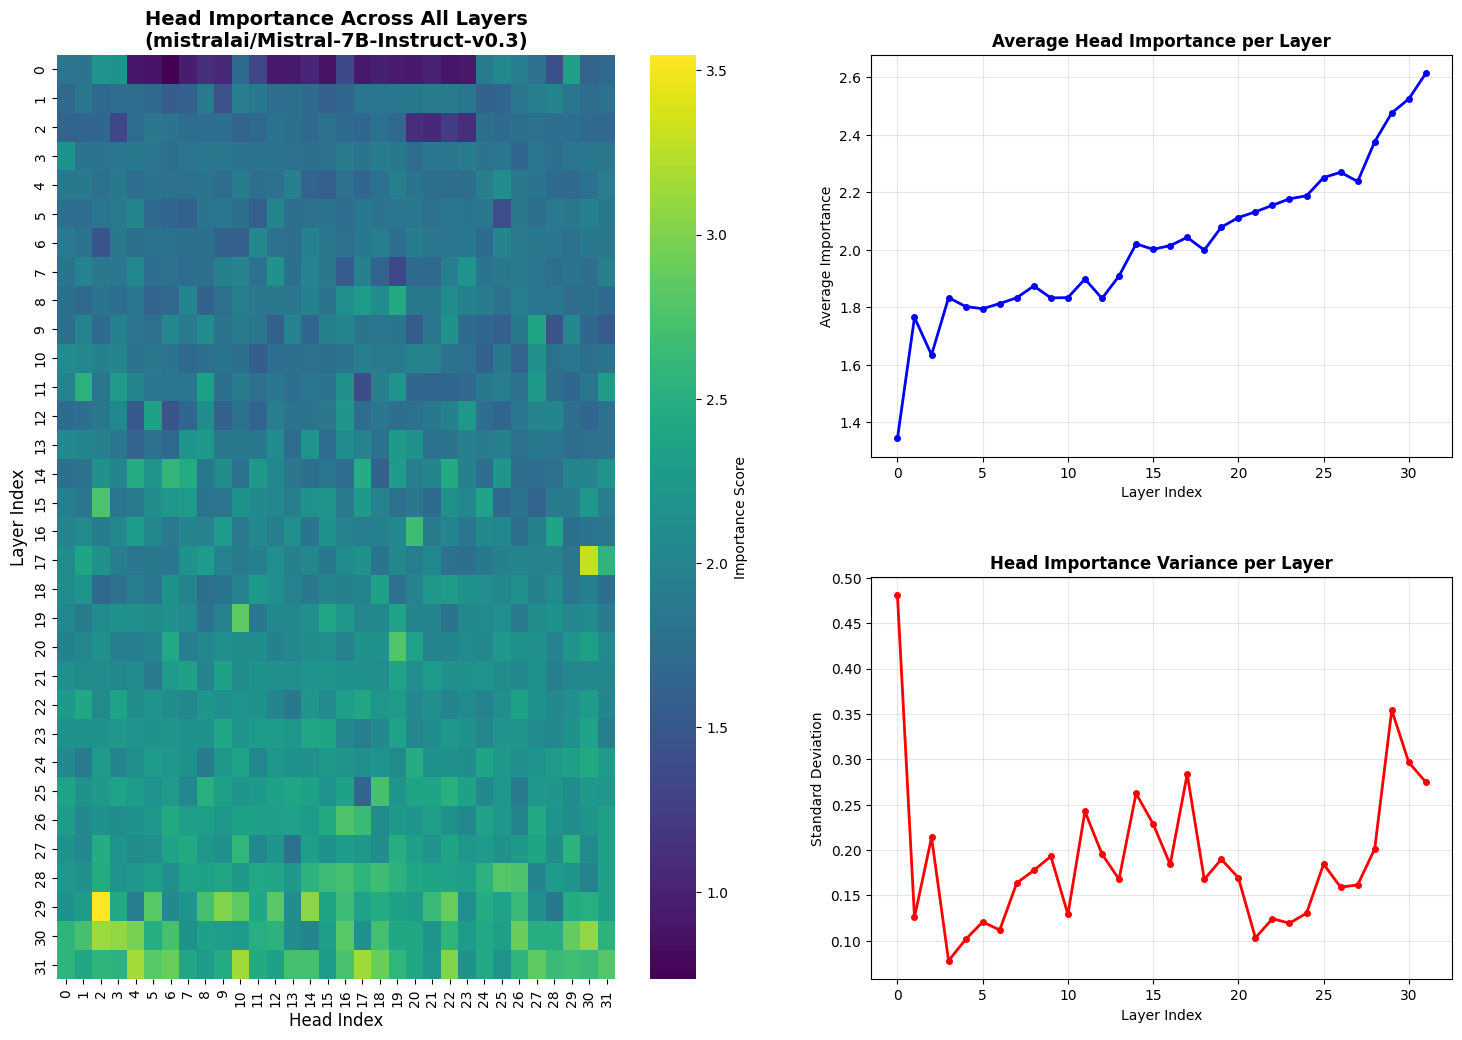


mistralai/Mistral-7B-Instruct-v0.3 Analysis Summary:
Score range: 0.734 to 3.547
Importance ratio: 4.83x
Mean importance: 2.021

Layer-wise insights:
Highest avg layer: Layer 31 (avg: 2.614)
Most variable layer: Layer 0 (std: 0.480)

Top 5 most important heads:
  Layer 29, Head 2: 3.547
  Layer 17, Head 30: 3.297
  Layer 31, Head 4: 3.172
  Layer 31, Head 10: 3.141
  Layer 31, Head 17: 3.141


In [43]:
# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

## Llama 70B

Loading checkpoint shards:  77%|███████▋  | 23/30 [00:01<00:00, 13.08it/s]

Loading checkpoint shards: 100%|██████████| 30/30 [00:02<00:00, 11.85it/s]


Number of layers: 80
W^O matrix shape per layer: torch.Size([8192, 8192])
Model config - Hidden size: 8192
Model config - Number of heads: 64
Importance matrix shape: (80, 64)
Score range: 4.438 to 20.125


/tmp/ipykernel_24675/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


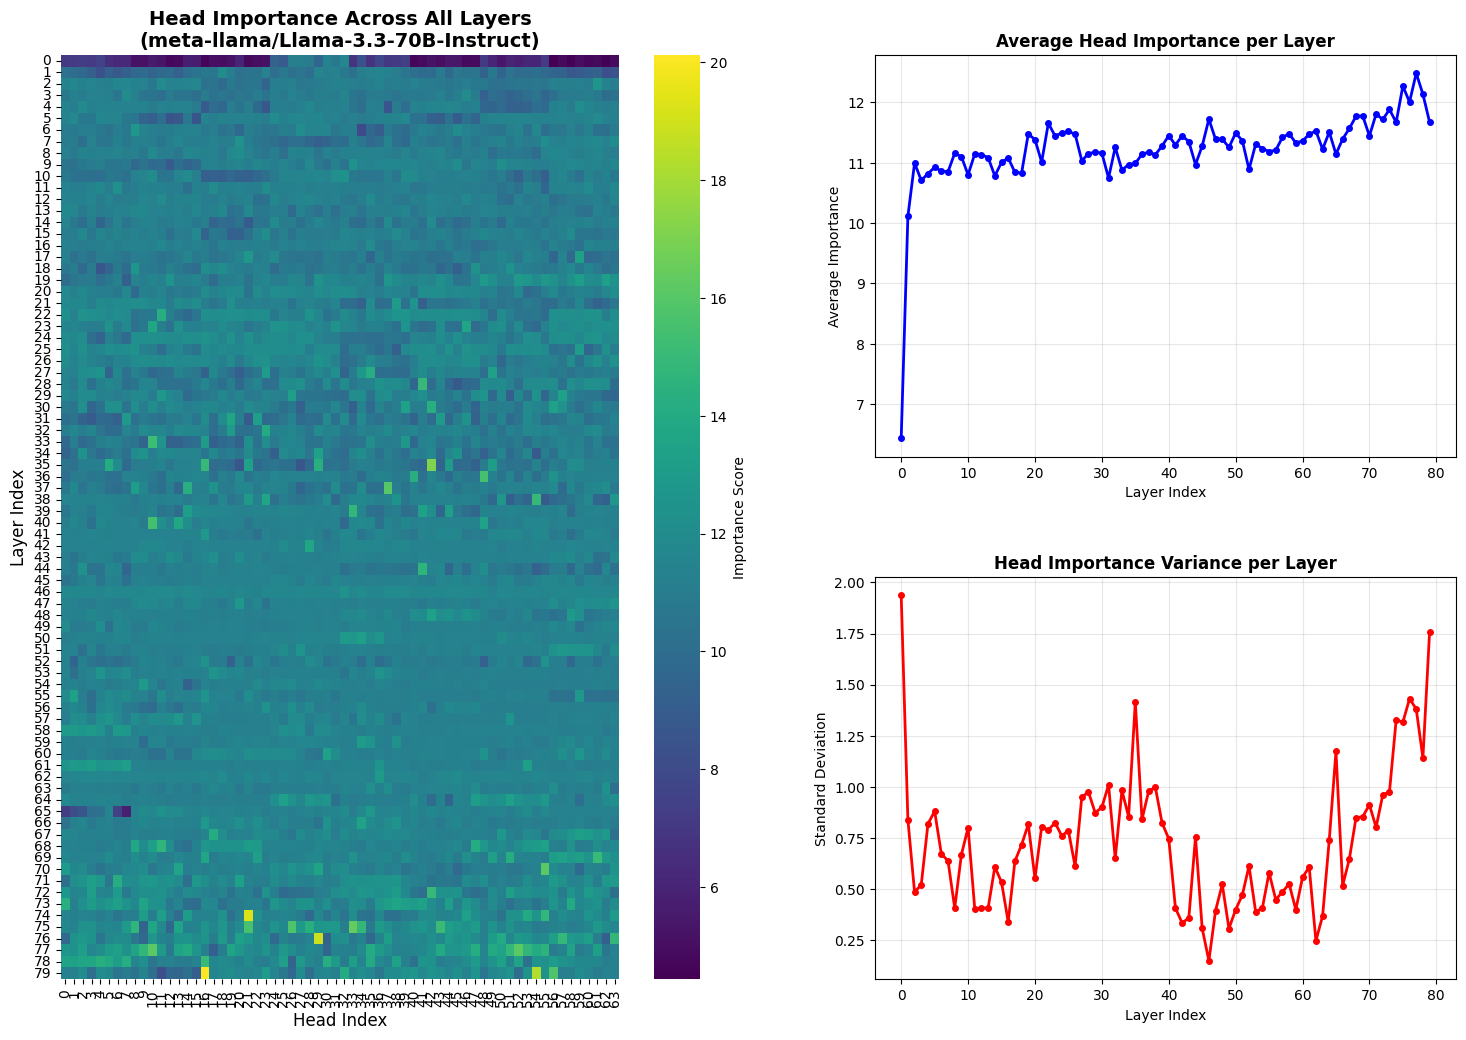


meta-llama/Llama-3.3-70B-Instruct Analysis Summary:
Score range: 4.438 to 20.125
Importance ratio: 4.54x
Mean importance: 11.231

Layer-wise insights:
Highest avg layer: Layer 77 (avg: 12.482)
Most variable layer: Layer 0 (std: 1.936)

Top 5 most important heads:
  Layer 79, Head 16: 20.125
  Layer 74, Head 21: 19.250
  Layer 76, Head 29: 18.875
  Layer 79, Head 54: 18.250
  Layer 35, Head 42: 17.125


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import LlamaModel, AutoTokenizer
import seaborn as sns

model_name = "meta-llama/Llama-3.3-70B-Instruct"
model = LlamaModel.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
#tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

## Qwen2.5-14B-Instruct-1M

Loading checkpoint shards: 100%|██████████| 8/8 [00:00<00:00, 12.68it/s]


Number of layers: 48
W^O matrix shape per layer: torch.Size([5120, 5120])
Model config - Hidden size: 5120
Model config - Number of heads: 40
Importance matrix shape: (48, 40)
Score range: 6.000 to 27.250


/tmp/ipykernel_46740/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


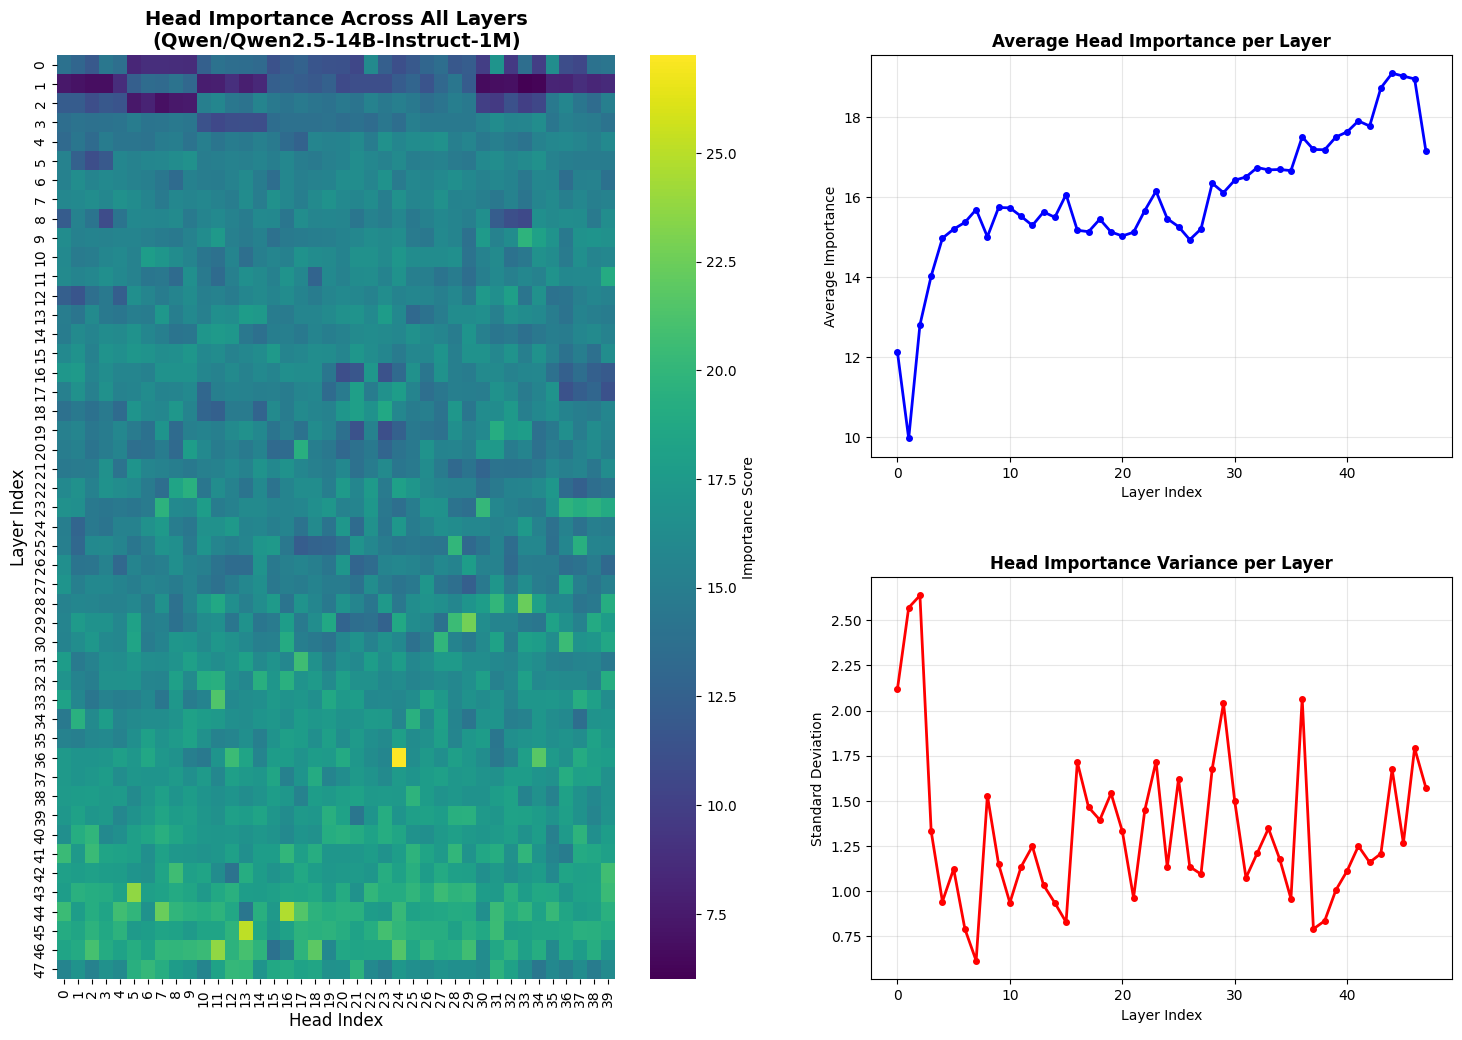


Qwen/Qwen2.5-14B-Instruct-1M Analysis Summary:
Score range: 6.000 to 27.250
Importance ratio: 4.54x
Mean importance: 15.963

Layer-wise insights:
Highest avg layer: Layer 44 (avg: 19.094)
Most variable layer: Layer 2 (std: 2.638)

Top 5 most important heads:
  Layer 36, Head 24: 27.250
  Layer 45, Head 13: 25.125
  Layer 44, Head 16: 24.750
  Layer 43, Head 5: 23.750
  Layer 46, Head 11: 23.750


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import seaborn as sns

model_name = "Qwen/Qwen2.5-14B-Instruct-1M"
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

## Deepseek R1 Reasoning Model
Does the learned matrix work differently for reasoning models?

Loading checkpoint shards: 100%|██████████| 8/8 [00:00<00:00, 12.44it/s]


Number of layers: 64
W^O matrix shape per layer: torch.Size([5120, 5120])
Model config - Hidden size: 5120
Model config - Number of heads: 40
Importance matrix shape: (64, 40)
Score range: 9.375 to 42.250


/tmp/ipykernel_49843/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


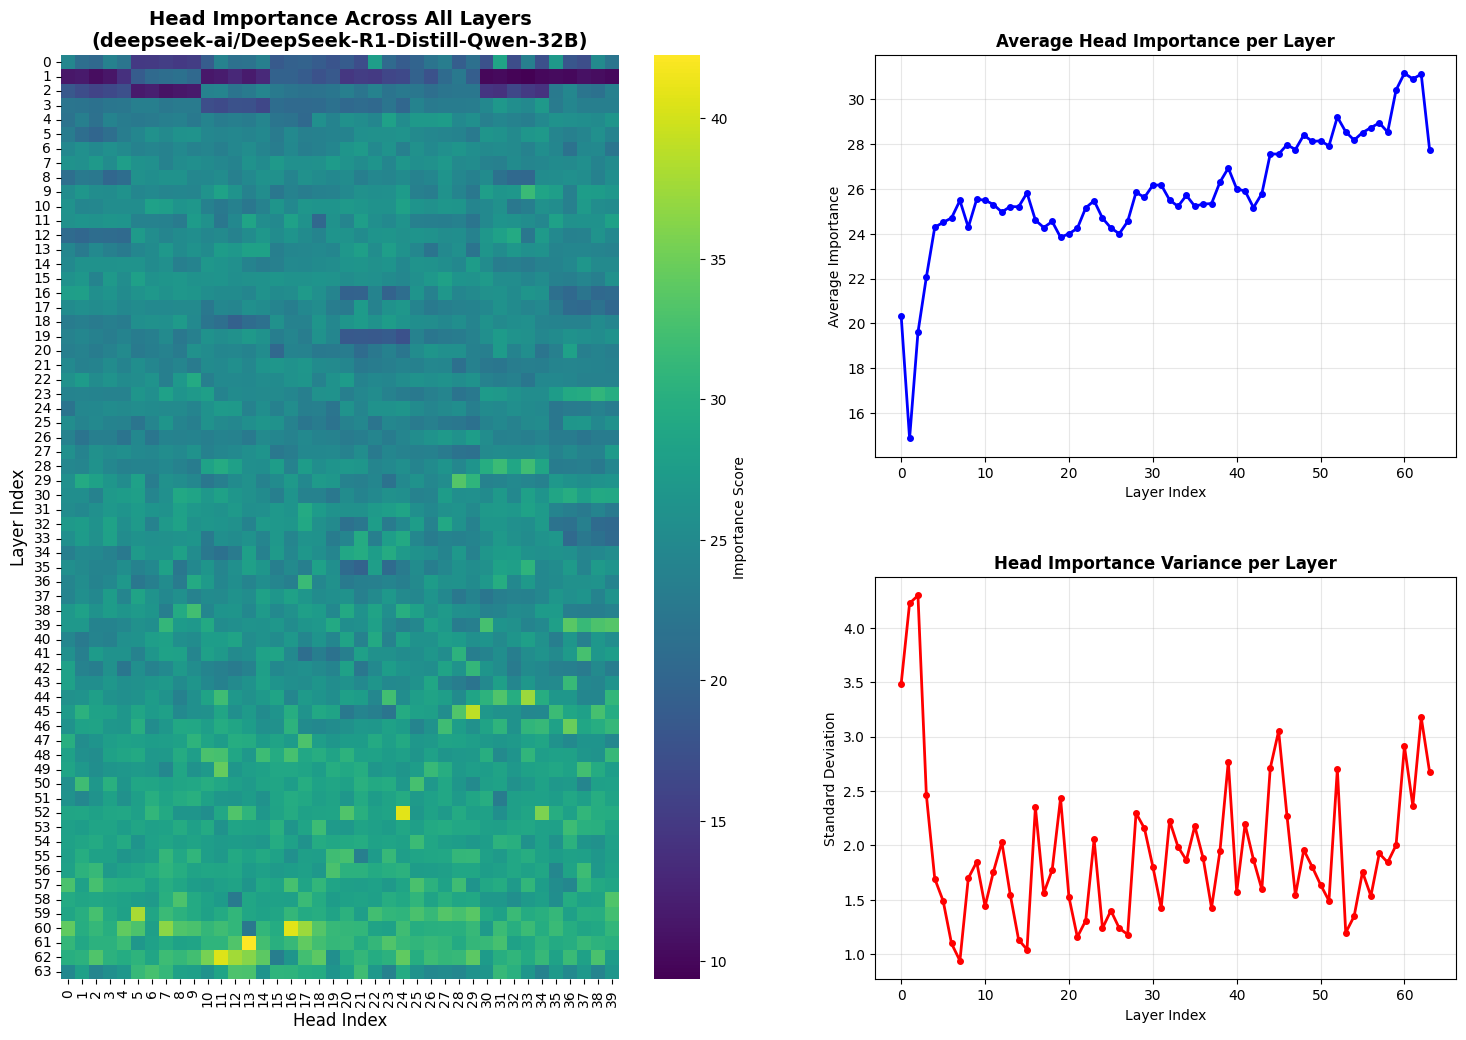


deepseek-ai/DeepSeek-R1-Distill-Qwen-32B Analysis Summary:
Score range: 9.375 to 42.250
Importance ratio: 4.51x
Mean importance: 25.919

Layer-wise insights:
Highest avg layer: Layer 60 (avg: 31.153)
Most variable layer: Layer 2 (std: 4.295)

Top 5 most important heads:
  Layer 61, Head 13: 42.250
  Layer 60, Head 16: 40.750
  Layer 52, Head 24: 40.750
  Layer 62, Head 11: 40.500
  Layer 45, Head 29: 39.000


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import seaborn as sns

model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-32B"
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

## Qwen2.5-1.5B-Instruct

Number of layers: 28
W^O matrix shape per layer: torch.Size([1536, 1536])
Model config - Hidden size: 1536
Model config - Number of heads: 12
Importance matrix shape: (28, 12)
Score range: 6.469 to 19.500


/tmp/ipykernel_61865/966542545.py:169: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


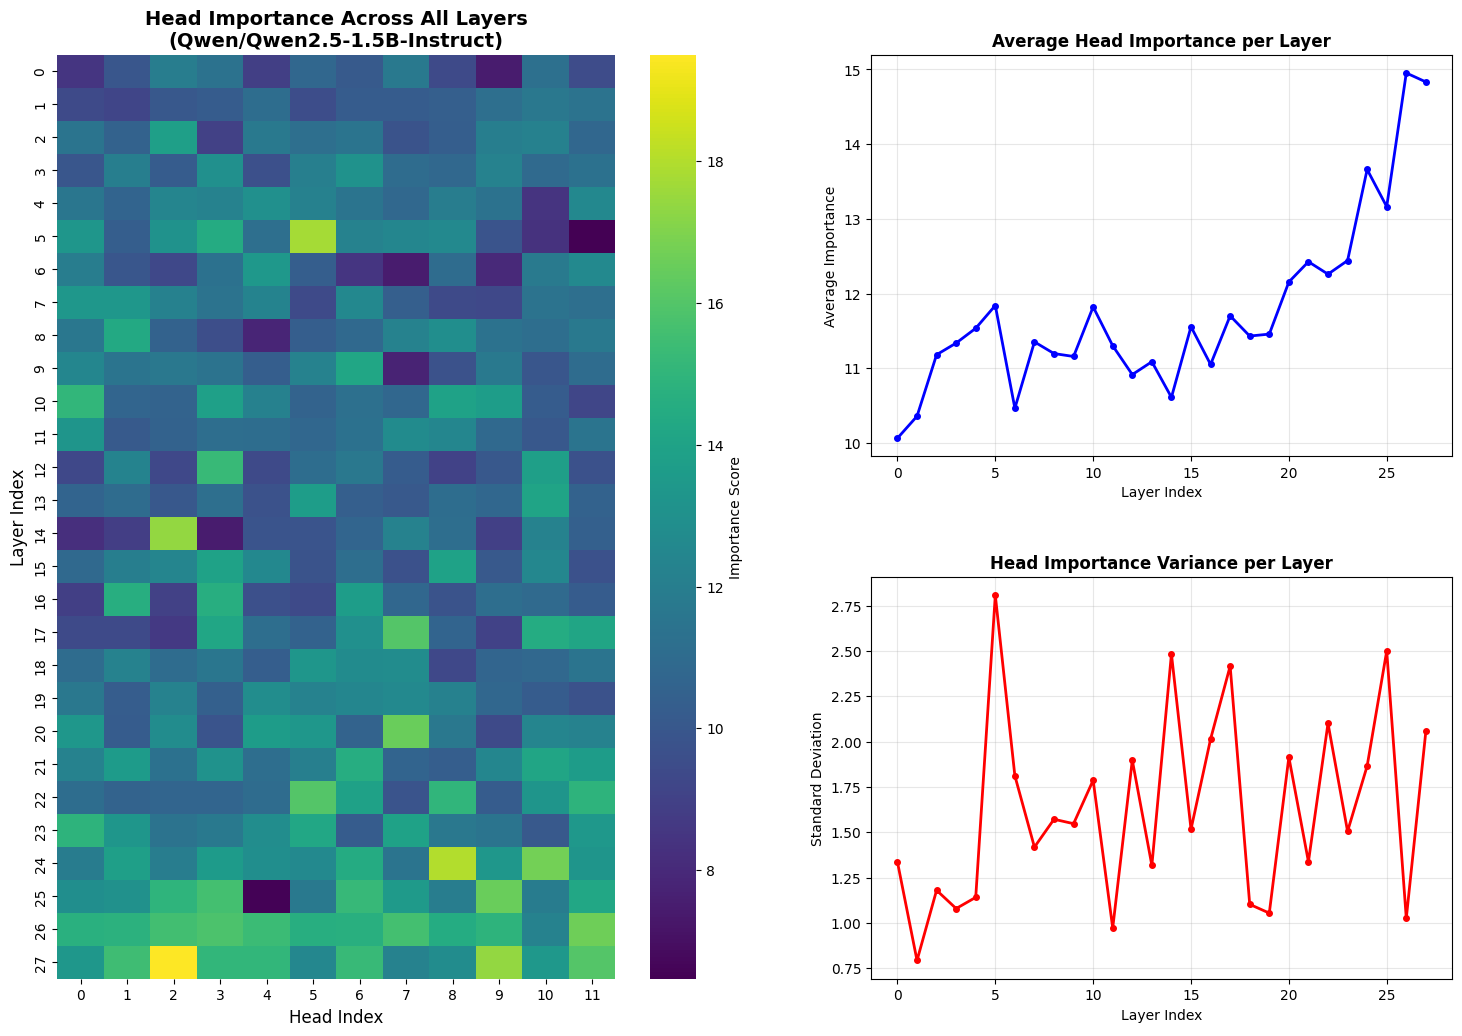


Qwen/Qwen2.5-1.5B-Instruct Analysis Summary:
Score range: 6.469 to 19.500
Importance ratio: 3.01x
Mean importance: 11.762

Layer-wise insights:
Highest avg layer: Layer 26 (avg: 14.953)
Most variable layer: Layer 5 (std: 2.807)

Top 5 most important heads:
  Layer 27, Head 2: 19.500
  Layer 24, Head 8: 18.000
  Layer 5, Head 5: 17.750
  Layer 14, Head 2: 17.375
  Layer 27, Head 9: 17.375


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
import seaborn as sns

model_name = "Qwen/Qwen2.5-1.5B-Instruct"
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.bfloat16, 
    device_map="cpu"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Extract all W^O matrices
wo_matrices = extract_wo_matrices(model)

# Print basic information
print(f"Number of layers: {len(wo_matrices)}")
print(f"W^O matrix shape per layer: {wo_matrices[0].shape}")
print(f"Model config - Hidden size: {model.config.hidden_size}")
print(f"Model config - Number of heads: {model.config.num_attention_heads}")

# Extract blocks for all layers
num_heads = model.config.num_attention_heads  # 32 for Llama-3.1-8B
head_dim = model.config.hidden_size // num_heads  # 4096 // 32 = 128

all_head_blocks = []
for layer_idx, wo_matrix in enumerate(wo_matrices):
    head_blocks = extract_wo_blocks_per_head(wo_matrix, num_heads, head_dim)
    all_head_blocks.append(head_blocks)
    # print(f"Layer {layer_idx}: Extracted {len(head_blocks)} head blocks, each shape {head_blocks[0].shape}")

# Compute importance scores
importance_scores = compute_head_importance_all_layers(model)
print(f"Importance matrix shape: {importance_scores.shape}")
print(f"Score range: {importance_scores.min():.3f} to {importance_scores.max():.3f}")

plot_head_importance_heatmap(importance_scores, model_name)

In [59]:
import gc
import torch

# More aggressive cleanup for Jupyter
def clear_memory_jupyter():
    # Clear all variables from global namespace
    for var in list(globals().keys()):
        if not var.startswith('_') and var not in ['gc', 'torch', 'clear_memory_jupyter']:
            try:
                del globals()[var]
            except:
                pass
    
    # Force garbage collection multiple times
    for _ in range(3):
        gc.collect()
    
    # Clear GPU cache aggressively
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
        torch.cuda.ipc_collect()  # Additional cleanup
    
    print("Aggressive memory cleanup completed")

# Use this instead of just del model
clear_memory_jupyter()


Aggressive memory cleanup completed
